# Metadata Health Report
### Built by Baibhav Prateek | OpenMetadata Hackathon 2026

## What is this?
This notebook analyzes the health of your OpenMetadata catalog.
It checks how well documented your data assets are.

## What it checks:-
1) How many tables have descriptions
2) How many tables have owners assigned
3) How many columns are missing descriptions
4) Overall health score out of 100

## Why this matters:
Poor metadata quality makes it hard for teams to find and 
trust their data, This report shows exactly where to improve!!!

In [1]:
import requests
import pandas as pd
from datetime import datetime

# Connection settings
BASE_URL = "https://sandbox.open-metadata.org"

# Paste your token here between the quotes
TOKEN = "your_openmetadata_token_here"

HEADERS = {
    "Authorization": f"Bearer {TOKEN}",
    "Content-Type": "application/json"
}

# Test connection
response = requests.get(
    f"{BASE_URL}/api/v1/tables",
    headers=HEADERS,
    params={"limit": 1}
)

print("Status code:", response.status_code)
if response.status_code == 200:
    print("✅ Connected to OpenMetadata successfully!")
else:
    print("❌ Error:", response.json())

Status code: 200
✅ Connected to OpenMetadata successfully!


In [3]:
# I am checking each table one by one
# For each table I want to know:
# Does it have a description? (so people know what it contains)
# Does it have an owner? (so people know who to contact)
# How many columns are missing descriptions?
def get_all_tables():
    response = requests.get(
        f"{BASE_URL}/api/v1/tables",
        headers=HEADERS,
        params={"limit": 50}
    )
    data = response.json()
    tables = data.get("data", [])
    return tables

print("⏳ Fetching tables...")
tables = get_all_tables()
print(f"✅ Found {len(tables)} tables!")

⏳ Fetching tables...
✅ Found 50 tables!


In [4]:
# Analyze table health
def analyze_health(tables):
    report = []
    
    for table in tables:
        name = table.get("name", "Unknown")
        description = table.get("description", "")
        owner = table.get("owner", None)
        followers = table.get("followers", 0)
        tags = table.get("tags", [])
        columns = table.get("columns", [])
        
        # Count columns missing descriptions
        cols_missing_desc = sum(
            1 for col in columns 
            if not col.get("description")
        )
        
        report.append({
            "Table Name": name,
            "Has Description": "✅" if description else "❌",
            "Has Owner": "✅" if owner else "❌",
            "Total Columns": len(columns),
            "Columns Missing Desc": cols_missing_desc,
            "Tags Count": len(tags),
        })
    
    return pd.DataFrame(report)

df = analyze_health(tables)
print("✅ Health analysis complete!")
print(df.to_string(index=False))

✅ Health analysis complete!
                     Table Name Has Description Has Owner  Total Columns  Columns Missing Desc  Tags Count
                       ACCOUNTS               ❌         ❌             32                    32           0
                       ACCOUNTS               ❌         ❌             32                    32           0
                       ACCOUNTS               ✅         ❌             32                    21           0
               acct_issue_table               ❌         ❌             15                    15           0
         _airbyte_raw_customers               ❌         ❌              3                     2           0
       _airbyte_raw_order_items               ✅         ❌              3                     3           0
            _airbyte_raw_orders               ❌         ❌              3                     3           0
            _airbyte_raw_staffs               ❌         ❌              3                     3           0
         

In [6]:
# Print a nice summary report
total = len(df)
has_description = (df["Has Description"] == "✅").sum()
missing_description = (df["Has Description"] == "❌").sum()
has_owner = (df["Has Owner"] == "✅").sum()
missing_owner = (df["Has Owner"] == "❌").sum()
total_columns = df["Total Columns"].sum()
columns_missing_desc = df["Columns Missing Desc"].sum()

print("=" * 50)
print("   📊 MY OPENMETADATA HEALTH REPORT")
print("   Built for OpenMetadata Hackathon 2026")
print("=" * 50)
print(f"  Total Tables Analyzed  : {total}")
print(f"  ✅ Have Description    : {has_description} ({round(has_description/total*100)}%)")
print(f"  ❌ Missing Description : {missing_description} ({round(missing_description/total*100)}%)")
print(f"  ✅ Have Owner          : {has_owner} ({round(has_owner/total*100)}%)")
print(f"  ❌ Missing Owner       : {missing_owner} ({round(missing_owner/total*100)}%)")
print(f"  Total Columns          : {total_columns}")
print(f"  Columns Missing Desc   : {columns_missing_desc}")
print("=" * 50)

# Health Score
score = round(((has_description + has_owner) / (total * 2)) * 100)
print(f"\n  🏥 Overall Health Score: {score}/100")
if score >= 70:
    print("  Status: 🟢 HEALTHY")
elif score >= 40:
    print("  Status: 🟡 NEEDS ATTENTION")
else:
    print("  Status: 🔴 CRITICAL")
print("=" * 50)

   📊 OPENMETADATA HEALTH REPORT
  Total Tables Analyzed  : 50
  ✅ Have Description    : 24 (48%)
  ❌ Missing Description : 26 (52%)
  ✅ Have Owner          : 0 (0%)
  ❌ Missing Owner       : 50 (100%)
  Total Columns          : 839
  Columns Missing Desc   : 762

  🏥 Overall Health Score: 24/100
  Status: 🔴 CRITICAL


In [7]:
# Print a nice summary report
total = len(df)
has_description = (df["Has Description"] == "✅").sum()
missing_description = (df["Has Description"] == "❌").sum()
has_owner = (df["Has Owner"] == "✅").sum()
missing_owner = (df["Has Owner"] == "❌").sum()
total_columns = df["Total Columns"].sum()
columns_missing_desc = df["Columns Missing Desc"].sum()

print("=" * 50)
print("   📊 OPENMETADATA HEALTH REPORT")
print("=" * 50)
print(f"  Total Tables Analyzed  : {total}")
print(f"  ✅ Have Description    : {has_description} ({round(has_description/total*100)}%)")
print(f"  ❌ Missing Description : {missing_description} ({round(missing_description/total*100)}%)")
print(f"  ✅ Have Owner          : {has_owner} ({round(has_owner/total*100)}%)")
print(f"  ❌ Missing Owner       : {missing_owner} ({round(missing_owner/total*100)}%)")
print(f"  Total Columns          : {total_columns}")
print(f"  Columns Missing Desc   : {columns_missing_desc}")
print("=" * 50)

# Health Score
score = round(((has_description + has_owner) / (total * 2)) * 100)
print(f"\n  🏥 Overall Health Score: {score}/100")
if score >= 70:
    print("  Status: 🟢 HEALTHY")
elif score >= 40:
    print("  Status: 🟡 NEEDS ATTENTION")
else:
    print("  Status: 🔴 CRITICAL")
print("=" * 50)

   📊 OPENMETADATA HEALTH REPORT
  Total Tables Analyzed  : 50
  ✅ Have Description    : 24 (48%)
  ❌ Missing Description : 26 (52%)
  ✅ Have Owner          : 0 (0%)
  ❌ Missing Owner       : 50 (100%)
  Total Columns          : 839
  Columns Missing Desc   : 762

  🏥 Overall Health Score: 24/100
  Status: 🔴 CRITICAL


In [8]:
# Save the report to a CSV file
df.to_csv("metadata_health_report.csv", index=False)
print("✅ Report saved as metadata_health_report.csv!")

# Also save summary
summary = {
    "Metric": [
        "Total Tables",
        "Tables With Description",
        "Tables Missing Description", 
        "Tables With Owner",
        "Tables Missing Owner",
        "Total Columns",
        "Columns Missing Description",
        "Health Score"
    ],
    "Value": [
        total, has_description, missing_description,
        has_owner, missing_owner,
        total_columns, columns_missing_desc,
        f"{score}/100"
    ]
}

summary_df = pd.DataFrame(summary)
summary_df.to_csv("metadata_health_summary.csv", index=False)
print("✅ Summary saved as metadata_health_summary.csv!")

✅ Report saved as metadata_health_report.csv!
✅ Summary saved as metadata_health_summary.csv!


Matplotlib is building the font cache; this may take a moment.
/var/folders/gm/42nd5n2d275gn5tbhsv4ms840000gn/T/ipykernel_88273/3804819565.py:35: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gm/42nd5n2d275gn5tbhsv4ms840000gn/T/ipykernel_88273/3804819565.py:36: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("metadata_health_chart.png", dpi=150, bbox_inches='tight')
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


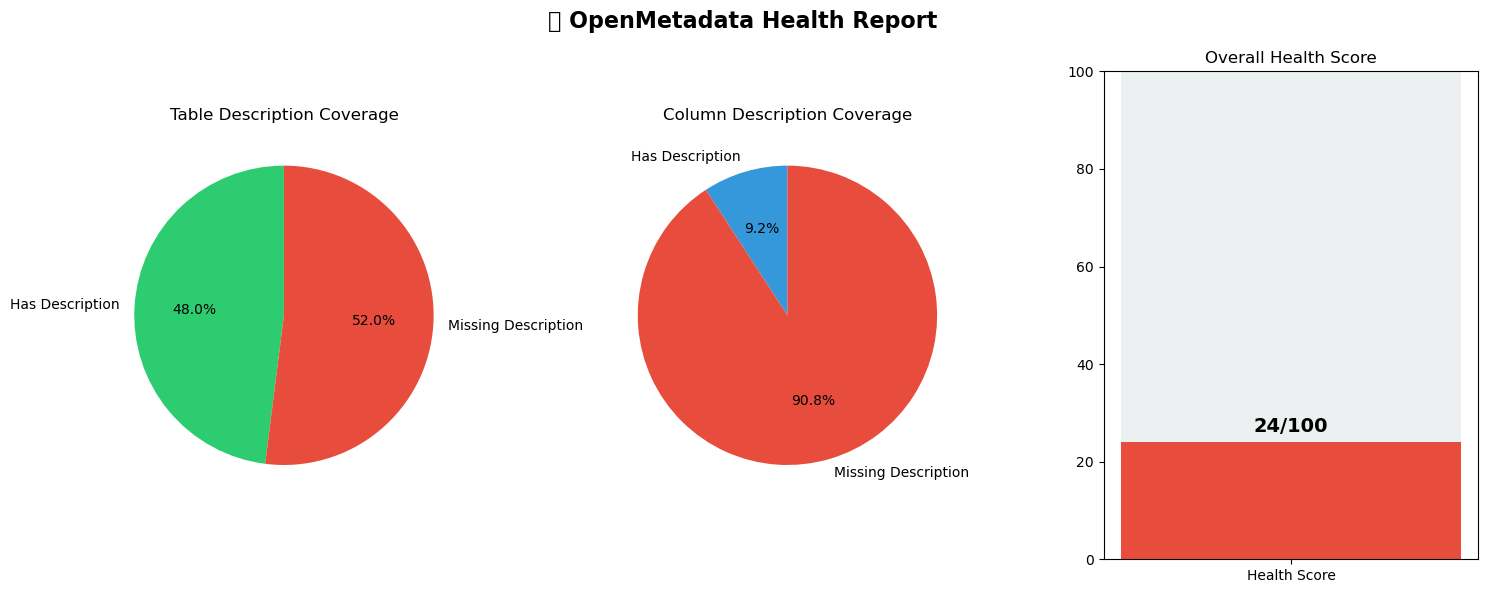

✅ Chart saved as metadata_health_chart.png!


In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle("📊 OpenMetadata Health Report", fontsize=16, fontweight='bold')

# Chart 1 - Description Coverage
axes[0].pie(
    [has_description, missing_description],
    labels=["Has Description", "Missing Description"],
    colors=["#2ecc71", "#e74c3c"],
    autopct="%1.1f%%",
    startangle=90
)
axes[0].set_title("Table Description Coverage")

# Chart 2 - Column Health
axes[1].pie(
    [total_columns - columns_missing_desc, columns_missing_desc],
    labels=["Has Description", "Missing Description"],
    colors=["#3498db", "#e74c3c"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Column Description Coverage")

# Chart 3 - Health Score Gauge
score_colors = ["#2ecc71" if score >= 70 else "#f39c12" if score >= 40 else "#e74c3c"]
axes[2].bar(["Health Score"], [score], color=score_colors, width=0.4)
axes[2].bar(["Health Score"], [100 - score], bottom=[score], color="#ecf0f1", width=0.4)
axes[2].set_ylim(0, 100)
axes[2].set_title("Overall Health Score")
axes[2].text(0, score + 2, f"{score}/100", ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("metadata_health_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as metadata_health_chart.png!")